## **Importing libraries**

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

## **Data loaded**

In [54]:
df = pd.read_csv('/content/drive/MyDrive/Nuclear_Analysis_project/data/owid-energy-data.csv')

## **Data exploration**

In [55]:
display(df.head())
print(df.info())
# checking null values
cols_to_check = ['country', 'year', 'nuclear_electricity', 'renewables_electricity', 'carbon_intensity_elec']
print(df[cols_to_check].isnull().sum())

,country,year,iso_code,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,...,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
0,ASEAN (Ember),2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
1,ASEAN (Ember),2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
2,ASEAN (Ember),2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
3,ASEAN (Ember),2003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
4,ASEAN (Ember),2004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23195 entries, 0 to 23194
Columns: 130 entries, country to wind_share_energy
dtypes: float64(127), int64(1), object(2)
memory usage: 23.0+ MB
None
country                       0
year                          0
nuclear_electricity       12570
renewables_electricity    13269
carbon_intensity_elec     17458
dtype: int64


## **We devided german data and checked quality**

In [56]:
germany = df[(df['country'] == 'Germany') & (df['year'] >= 1990)].copy()

print(f"Total data point of germany: {len(germany)}")
print("checking null values in german data:")
print(germany[cols_to_check].isnull().sum())

Total data point of germany: 35
checking null values in german data:
country                    0
year                       0
nuclear_electricity        0
renewables_electricity     0
carbon_intensity_elec     10
dtype: int64


## **Defined features and target**

In [57]:
features = ['year', 'nuclear_electricity', 'renewables_electricity', 'coal_electricity', 'gas_electricity']
target = 'carbon_intensity_elec'
print(f"Features list has been generated: {features}")

Features list has been generated: ['year', 'nuclear_electricity', 'renewables_electricity', 'coal_electricity', 'gas_electricity']


## **Now we are cleaning our data**

In [58]:
data = germany[cols_to_check + ['coal_electricity', 'gas_electricity']].dropna()
print(f"\nRemaninng after cleaning our data point: {len(data)}")


Remaninng after cleaning our data point: 25


## **Saving processed data**

In [59]:
data.to_csv('/content/drive/MyDrive/Nuclear_Analysis_project/processed data.csv', index=False)

## **Now it is time to do visualization**

In [60]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 150

First graph is our energy mixed evaluation

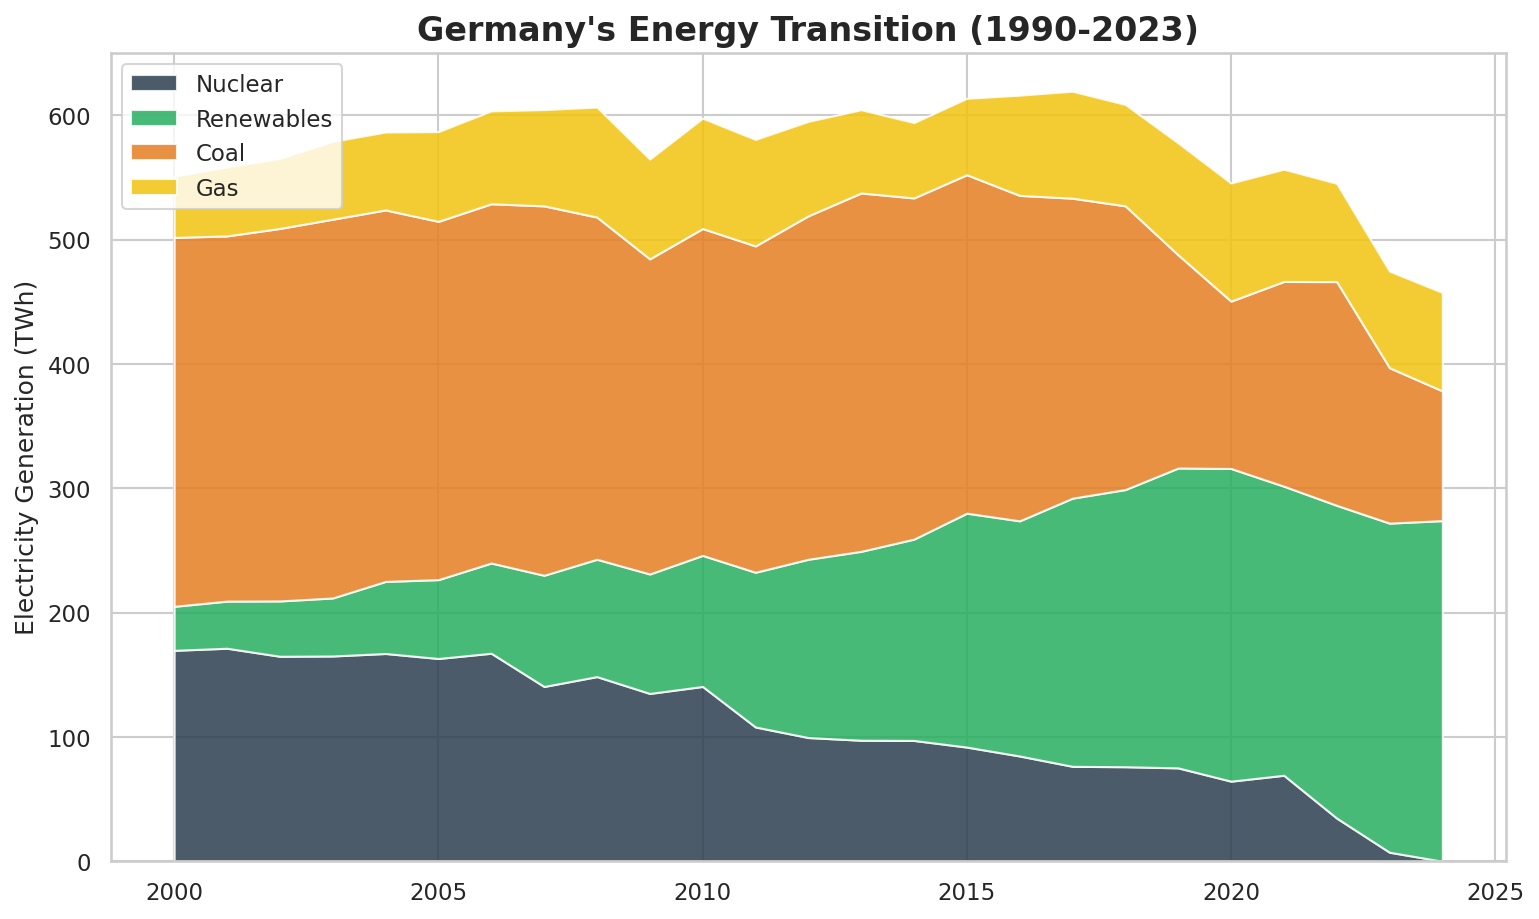

In [61]:
plt.figure(figsize=(12, 7))
colors = ['#2C3E50', '#27AE60', '#E67E22', '#F1C40F']
plt.stackplot(data['year'],
              data['nuclear_electricity'],
              data['renewables_electricity'],
              data['coal_electricity'],
              data['gas_electricity'],
              labels=['Nuclear', 'Renewables', 'Coal', 'Gas'],
              alpha=0.85, colors=colors, edgecolor='white')

plt.title("Germany's Energy Transition (1990-2023)", fontsize=16, fontweight='bold')
plt.ylabel("Electricity Generation (TWh)")
plt.legend(loc='upper left')
plt.savefig('/content/drive/MyDrive/Nuclear_Analysis_project/figures/energy_mix_advanced.png')
plt.show()

Second graph is about Nuclear Phase-out vs Carbon Intensity

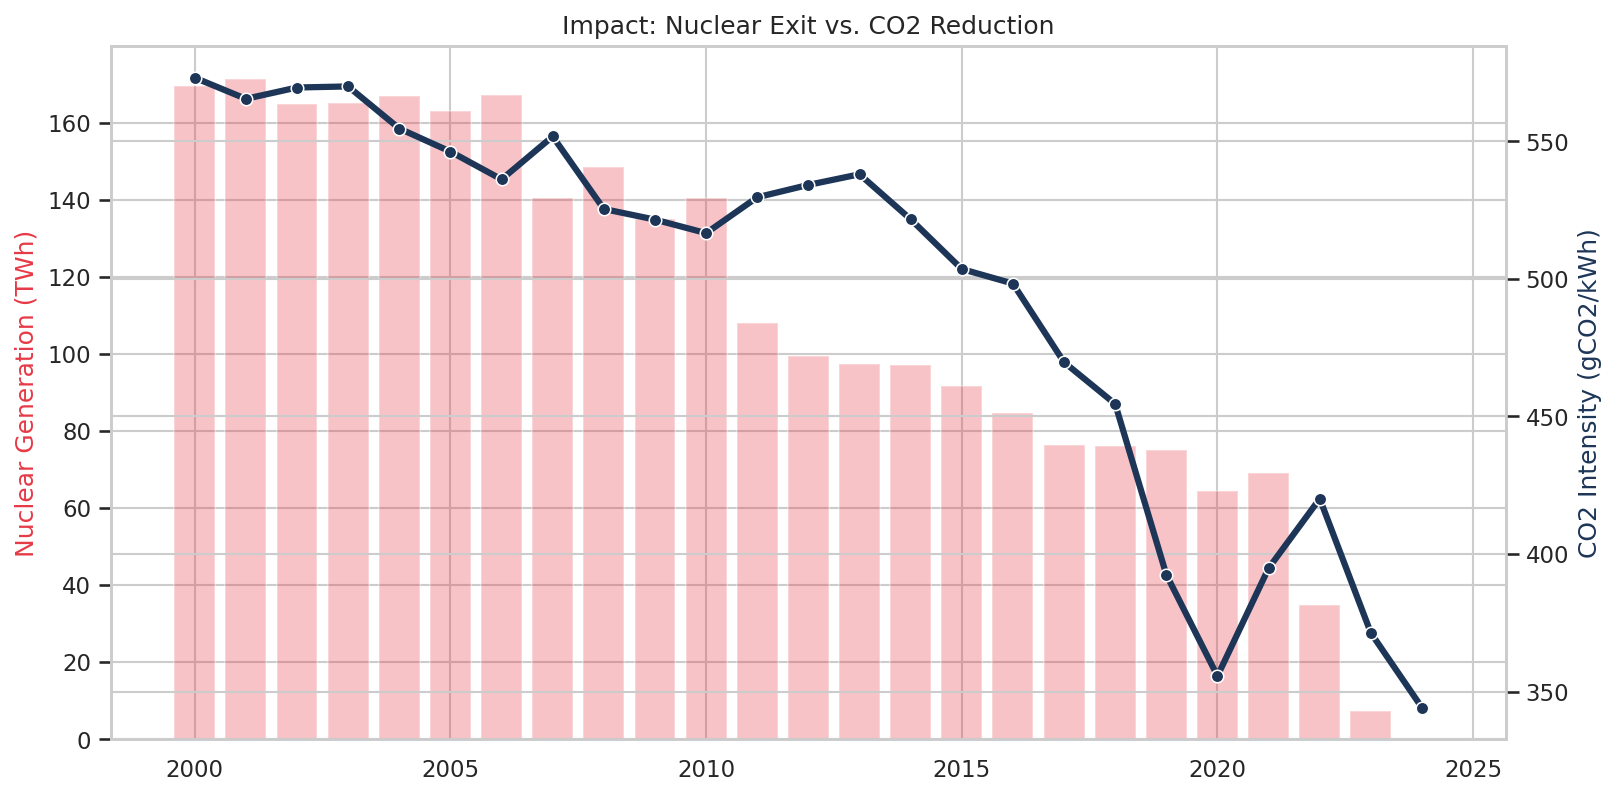

In [62]:
fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.bar(data['year'], data['nuclear_electricity'], color='#E63946', alpha=0.3, label='Nuclear')
ax1.set_ylabel('Nuclear Generation (TWh)', color='#E63946')

ax2 = ax1.twinx()
sns.lineplot(x=data['year'], y=data['carbon_intensity_elec'], ax=ax2, color='#1D3557', linewidth=3, marker='o')
ax2.set_ylabel('CO2 Intensity (gCO2/kWh)', color='#1D3557')

plt.title("Impact: Nuclear Exit vs. CO2 Reduction")
plt.savefig('/content/drive/MyDrive/Nuclear_Analysis_project/figures/impact_analysis_dual.png')
plt.show()

## **Model training**

In [63]:
X = data[features]
y = data[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

Model accuracy checked

In [64]:
print(f"\nModel accuracy:(R2 Score): {r2_score(y_test, rf_model.predict(X_test)):.4f}")


Model accuracy:(R2 Score): 0.9907


## **Feature importance**

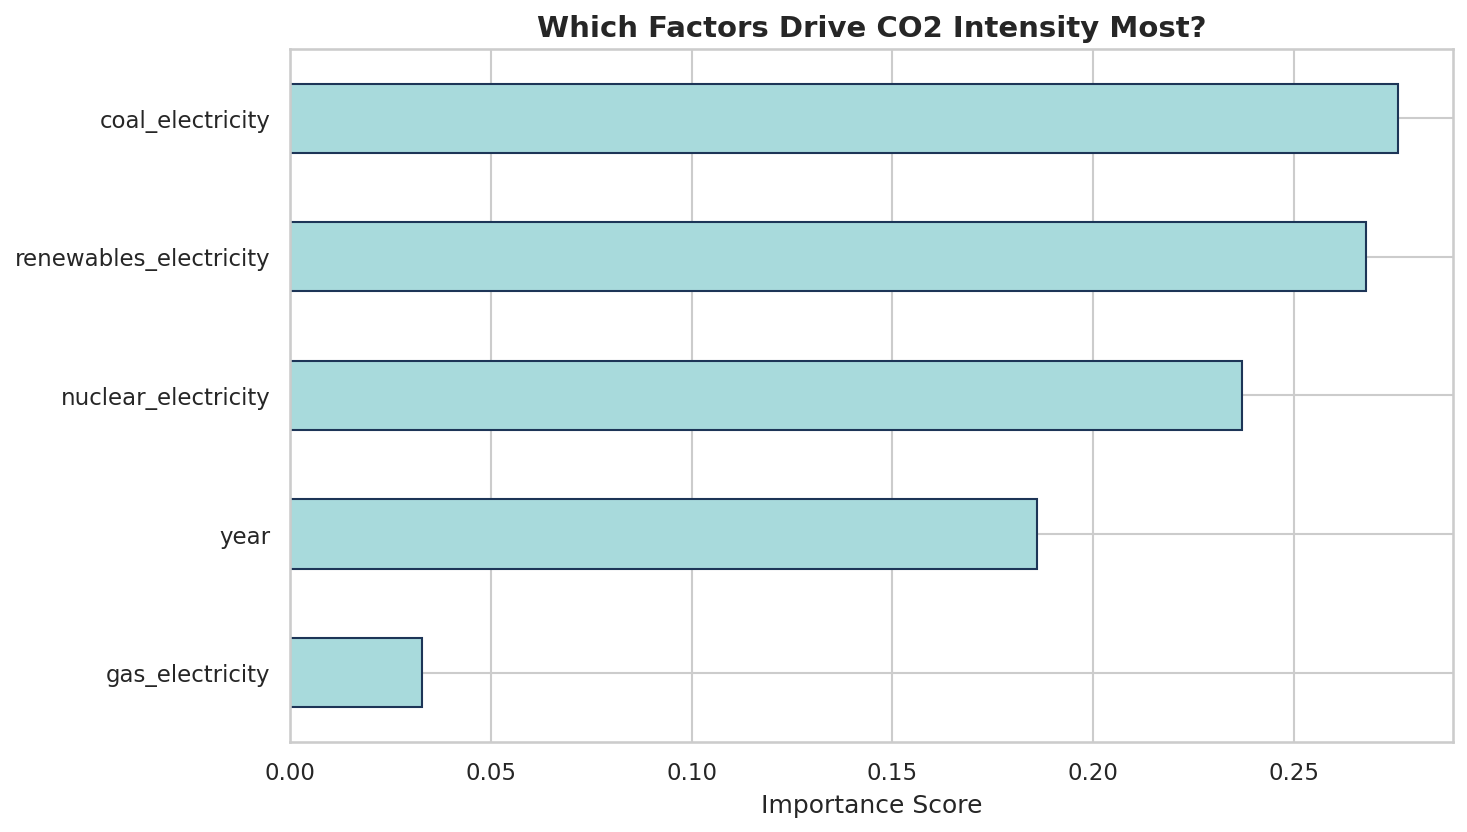

In [65]:
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values()
plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='#A8DADC', edgecolor='#1D3557')
plt.title("Which Factors Drive CO2 Intensity Most?", fontsize=14, fontweight='bold')
plt.xlabel("Importance Score")
plt.savefig('/content/drive/MyDrive/Nuclear_Analysis_project/figures/feature_importance_rf.png')
plt.show()

## **Model saved**

In [66]:
import joblib
model_path = '/content/drive/MyDrive/Nuclear_Analysis_project/models/germany_energy_model.pkl'
joblib.dump(rf_model, model_path)

['/content/drive/MyDrive/Nuclear_Analysis_project/models/germany_energy_model.pkl']